In [1]:
import ucdmcmc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("/Users/epritchard/Research/")
import TAPS
import emcee
import scipy.interpolate
import corner
import copy



Welcome to the UCDMCMC spectral fitting code!
This code is designed to conduct both grid and MCMC fitting of spectral data of ultracool dwarfs
You are currently using version dated 2026.04.03

If you make use of this code for your research, please remember to cite our Zenodo DOI:
	10.5281/zenodo.16923762 (https://doi.org/10.5281/zenodo.16923762)
If you make use of any spectra or models in this toolkit, please remember to cite the original source.
Please report any errors are feature requests to our github page, http://www.github.com/aburgasser/ucdmcmc/


Currently running in error checking mode


Welcome to the Spex Prism Library Analysis Toolkit (SPLAT)!
You are currently using version 2025.12.26

If you make use of any features of this toolkit for your research, please remember to cite the SPLAT paper:

Burgasser et al. (2017, Astro. Soc. India Conf. Series 14, p. 7); Bibcode: 2017ASInC..14....7B

If you make use of any spectra or models in this toolkit, please remember to cite the

In [27]:
def fitMCMC(spc,models,p0={},plimits={},constraints={},flux_name=ucdmcmc.DEFAULT_FLUX_NAME,output='all',
	pstep=ucdmcmc.DEFAULT_MCMC_STEPS,nstep=100,iterim=50,method='chidiff',threshhold=0.5,burn=0.25,
	quantscale=[0.25,0.5,0.75],nsample=0,absolute=False,report=True,xscale='linear',yscale='linear',
	file_prefix='mcmcfit_',verbose=ucdmcmc.ERROR_CHECKING):
#	radius=np.nan,e_radius=np.nan,report=True):
	'''
	Purpose
	-------

	Fit a spectrum to model grid using a simple Metropolis-Hastings Markov Chain Monte Carlo methor. Conducts the fit
	through model grid by interpolating (logarithmic) fluxes, and advances chains based on various chi-square comparison
	statistics. Returns a variety of outputs depending on the output and report keywords.

	Parameters
	----------

	ref : spc
		A Spectrum class object that contains the spectrum to be fit, assumed to be onthe same wavelength scale as the models

	models: pandas DataFrame
		A pandas DataFrame that is read in through `readModels()` or `getModelSet()` that contains the model parameters 
		and associated flux arrays

	p0 = {} : dict
		Dictionary containing the initial parameters; if not provided or some parameters missing, default parameters are
		used from the DEFINED_SPECTRAL_MODELS parameter

	contraints = {} : dict
		Optional parameter constraints, with the keys corresponding to the model parametes associated with 2-element
		arrays that specify the lower and upper limits. NOTE: currently only works with quantitative variables

	output = 'all' : str
		Specify what the function should return; options are:
			* 'best': return a dict of the best-fit model parameters
			* 'model': return the best fit model as a Spectrum class object
			* 'distribution': return a dict of the model parameter distributions (25%, 50%, and 75% quantiles)
			* 'chain': return the chain of parameter values as a pandas Dataframe
			* 'all' (DEFAULT): returns a dict containing all three of the above 

	pstep = DEFAULT_MCMC_STEPS : dict
		Dictionary containing the parameter step scales. New parameers are selected by a normal distribution with the step
		width, up to the parameter limits

	nstep = 100 : int
		Number of MCMC steps to take; ideally this should be 1000-10000+

	iterim = 50 : int
		If > 0 and report = True, this will iteratively save the chains and diagnostic plots on a cadence of iterim steps

	method = 'chidiff' : str
		The method by which the current (i) and previous (i-1) model fit chi2 values are compared; options are:
			* 'chidiff' (DEFAULT): compare difference in chis to overall miniumum chi2: (chi2[i]-chi2[i-1])/min(chi2)
			* 'survival': compute the F-test survival fraction for the ratio of chi2 values: SF(chi2[i]/chi2[i-1],dof,dof)
			 (see scipy.stats.f)
			* 'dofscale': compares the difference in chi2 values to the dof: dof/(0.5*dof+chi2[1]-chi2[-1])
	treshhold = 0.5 : float
		A scaling factor to determine the acceptance rate for new parameters, where the comparison statistic is compared to a
		uniform draw between [0,threshhold] or [threshhold,1] (depending on the statistic)

	burn = 0.25 : float
		The fraction of the initial chain to remove before determining the final parameter distributions. Set to a low fraction
		if you are starting with a good approximation of the model parameters

	quantscale = [0.25,0.5,0.75] : list
		List of three floats indicating the quantile scales to report for the parameter distributions

	nsample = 0 : int
		For the comparison plot, set to 0 to compare to the best fit model, or to a positive integer to compare to nsample models
		drawn from the chain

	xscale = 'linear' : str
		Scaling of the x-axis, based on the options in matplotlib.set_xscale()

	yscale = 'linear' : str
		Scaling of the y-axis, based on the options in matplotlib.set_xscale()

	absolute = True : bool
		Set to True if spectrum fluxes are in absolute flux units (flux at 10 pc), such that the optimal scaling factor 
		provides a realistic estimate of the radius

	report = True : bool
		Set to True to save both the chains and several diagnostic plots

	file_prefix = 'mcmcfit_' : str
		Prefix to append to output files if report = True

	verbose = ERROR_CHECKING : bool
		Set to True to return verbose output

	Outputs
	-------
	
	Determined by the `output` keyword; options are:
		* 'best': return a dict of the best-fit model parameters
		* 'model': return the best fit model as a Spectrum class object
		* 'distribution': return a dict of the model parameter distributions (25%, 50%, and 75% quantiles)
		* 'chain': return the chain of parameter values as a pandas Dataframe
		* 'all' (DEFAULT): returns a dict containing all three of the above 

	Example
	-------

	>>> import ucdmcmc
	>>> sp = ucdmcmc.getSample('JWST-NIRSPEC-PRISM')
	>>> models,wave = ucdmcmc.getModelSet('sonora21','JWST-NIRSPEC-PRISM')
	>>> spsm = ucdmcmc.resample(sp,wave)
	>>> par0 = ucdmcmc.fitGrid(spsm,models,verbose=False) # initial fit
	>>> par = ucdmcmc.fitMCMC(spsm,models,p0=par0,nstep=1000,burn=0.25,verbose=False) # MCMC
	>>> par['distributions']
	{'co': array([0.54139703, 0.88476726, 1.25166873]),
	  'kzz': array([2.17372842, 2.90277005, 3.99281996]),
	  'logg': array([4.693938  , 5.10931096, 5.41861495]),
	  'teff': array([ 976.68788945, 1033.00133369, 1090.21418499]),
	  'z': array([-0.35613309, -0.12806126,  0.12211709])}

	Dependencies
	------------
		
	`compareSpec()`
	`getGridModel()`
	`plotCopmare()`
	astropy.unit
	copy
	numpy
	pandas

	'''
# make sure object spectrum is sampled to same wavelength scale as models
#	print(constraints,plimits)
	if len(spc.flux)!=len(models.loc[0,flux_name]):
		raise ValueError('Spectrum and models are not on same wavelength scale; be sure to resample observed spectrum onto model scale')
	spscl = copy.deepcopy(spc)

# backwards compatability for constraint keyword
	if len(list(constraints.keys()))>0:
#		print('Warning: constraints keyword will be deprecated in future version; use plimits instead')
		plimits = copy.deepcopy(constraints)

# constrain models if needed
	mdls = copy.deepcopy(models)
	for k in list(plimits.keys()):
		if k in list(mdls.columns):
			if isinstance(mdls.loc[0,k],str):
				if len(plimits[k])>0:
					par = list(set(list(mdls[k])))
#					print(k,par,plimits[k])
					if verbose==True: print('Constraining {} to within {}'.format(k,plimits[k]))
					for p in par:
						if p not in plimits[k]: 
							mdls = mdls[mdls[k]!=p]
							mdls.reset_index(inplace=True,drop=True)
			else:
				if verbose==True: print('Constraining {} to {}-{}'.format(k,plimits[k][0],plimits[k][1]))
				mdls = mdls[mdls[k]>=plimits[k][0]]
				mdls = mdls[mdls[k]<=plimits[k][1]]
				mdls.reset_index(inplace=True,drop=True)
	mset = mdls.loc[0,'model']
	mkys = list(mdls.keys())
	for x in ['model','file',flux_name]:
		if x in mkys: mkys.remove(x)

# if no or incomplete fit parameters, conduct an initial grid fit
	chk = True
	for k in mkys: chk=(chk and (k in list(p0.keys())))
	if chk==False:
		if verbose==True: print('Running initial grid fit')
		p0 = ucdmcmc.fitGrid(spc,mdls,absolute=absolute,plimits=plimits,report=False,verbose=False)
		if flux_name in list(p0.keys()): del p0[flux_name]
		if verbose==True: print('\nGrid fit parameters: {}'.format(p0))

# determine the model parameters that can be varied
	mkysfit = copy.deepcopy(mkys)
	for x in ['file','model','scale','dof','rchi']:
		if x in mkysfit: mkysfit.remove(k)
	for k in mkys:
		vals = list(set(list(mdls[k])))
		vals.sort()
		if len(vals)<2: pstep[k] = 0.
		else:
			if k not in list(pstep.keys()):
				if isinstance(vals[0],str): pstep[k] = -1.
				else: pstep[k] = 0.5*np.nanmedian(np.absolute(np.array(vals)-np.roll(vals,1)))
		if pstep[k] == 0: mkysfit.remove(k)

# add in alternate parameters if present
	for k in ucdmcmc.ALT_PARAMETERS:
		if k in list(p0.keys()):
			if k not in list(pstep.keys()): pstep[k] = 0
			if pstep[k] > 0: 
				mkysfit.append(k)
	nparam = len(mkysfit)

# set defaults for required model parameters
	for k in mkysfit: 
		if k not in list(p0.keys()):
			if k in list(mdls.columns): p0[k] = ucdmcmc.DEFINED_SPECTRAL_MODELS[mset]['default'][k]
			elif k in list(ucdmcmc.PARAMETERS.keys()): p0[k] = ucdmcmc.PARAMETERS[k]['default']
			else: 
				if verbose==True: print('Warning: dropping parameter {} as no default value provided'.format(k))
				mkysfit.remove(k)
				nparam = len(mkysfit)

# set limits for fitting parameters
	for k in mkysfit: 
		if k not in list(plimits.keys()):
			if k in list(mdls.columns): 
				vals = list(set(list(mdls[k])))
				vals.sort()
				if isinstance(vals,str)==False: plimits[k] = [vals[0],vals[-1]]
				else: plimits[k] = vals
			elif k in list(ucdmcmc.PARAMETERS.keys()): plimits[k] = ucdmcmc.PARAMETERS[k]['limits']
			else: plimits[k] = [p0[k],p0[k]]

# organize into continuous and discrete variables
	pfitc,pfitd = {},{}
	if verbose==True: print('Fitting the following parameters:')
	for k in mkysfit: 
		if k in list(p0.keys()):
			if isinstance(p0[k],str)==True: 
				pfitd[k] = p0[k]
				if verbose==True: print('\t{}: initial={} (discrete)'.format(k,p0[k]))
			else: 
				pfitc[k] = p0[k]
				if verbose==True: print('\t{}: initial={} step={} min={} max={}'.format(k,p0[k],pstep[k],plimits[k][0],plimits[k][1]))

	return pfitc, pfitd, plimits
# 		else: 
# 			if k in list(PARAMETERS.keys()):

# 				if PARAMETERS[k]['type'] == str: p
# 				else: pfitc[k] = p0[k]
# 			elif k in list(mdls.columns):
# 				if isinstance(mdls.loc[0,k],str): pfitd[k] = p0[k]
# 				else: pfitc[k] = p0[k]
# 			else: 
# 			default = DEFINED_SPECTRAL_MODELS[mset]['default'][k]
# #			default = splat.SPECTRAL_MODELS[mset]['default'][k]
# 			if isinstance(default,str): pfitd[k] = default
# 			else: pfitc[k] = default

# # some plotting set up
# 	ylabelpre = 'Scaled '
# 	if absolute==True: ylabelpre='Absolute '

# # initialize MCMC
# 	cmdl = getModel(mdls,p0,spscl.wave,scale=False,verbose=verbose)
# 	chi,scl,dof = compareSpec(spscl.flux.value,cmdl.flux.value,spscl.noise.value,verbose=verbose)
# 	dof = dof-nparam
# 	cmdl.scale(scl) 
# 	chis = [chi]
# 	pvals = [p0]
# 	mdlflxs = [cmdl.flux.value]
# 	scales = [scl]

# # run MCMC
# 	if verbose==True: print('Running MCMC for {:.0f} steps'.format(nstep))
# 	for i in tqdm(range(nstep)):
# 		pnew = copy.deepcopy(pvals[-1])
# # continuous variables		
# # constrain to be within specified limits
# 		for k in list(pfitc.keys()): 
# 			pnew[k] = np.random.normal(pvals[-1][k],pstep[k])
# 			pnew[k] = np.nanmin([pnew[k],np.nanmax(plimits[k])])
# 			pnew[k] = np.nanmax([pnew[k],np.nanmin(plimits[k])])
# # discrete variables
# 		for k in list(pfitd.keys()): 
# #			vals = list(set(list(mdls[k])))
# 			pnew[k] = np.random.choice(plimits[k])
# # do we need this next line?			
# #		pnew = pnew | pfitd
# # try grid model			
# 		try:
# 			cmdl = getModel(mdls,pnew,spscl.wave,scale=False,verbose=verbose)
# # try interpolated model			
# 		# except:
# 		# 	cmdl = getInterpModel(mdls,pnew,spscl.wave,scale=False,verbose=verbose)
# # model can't be read, stay in place
# 		except: 
# 			if verbose==True: print('Error reading in parameters {}'.format(pnew))
# 			pvals.append(pvals[-1])
# 			chis.append(chis[-1])
# 			scales.append(scales[-1])
# 			mdlflxs.append(mdlflxs[-1])
# # compare model			
# 		else:
# #			if verbose==True: print(i,pnew)
# 			chinew,scl,_ = compareSpec(spscl.flux.value,cmdl.flux.value,spscl.noise.value,verbose=verbose)
# 			# if np.isnan(radius)==False and np.isnan(e_radius)==False:
# 			#	 chinew+=(((10.*u.pc*(scl**0.5)).to(u.Rsun).value-radius)/e_radius)**2
# 			#if 'scale' not in list(pnew.keys()): cmdl.scale(scl)

# 	# compute statistic
# 			if method=='chidiff': st,chst = (chinew-chis[-1])/np.nanmin(chis),np.random.uniform(0,threshhold)
# 			elif method=='survival': st,chst = 2*stats.f.sf(chinew/chis[-1],dof,dof),np.random.uniform(threshhold,1)
# 			elif method=='dofscale': st,chst = dof/(0.5*dof+chinew-chis[-1]),np.random.uniform(threshhold,1)
# 			else: raise ValueError('Do not recognize statistical comparison {}; try chidiff, survival, or dofscale'.format(method))
# 	#			if verbose==True: print(chinew,chis[-1],dof,st,chst)

# 			if st<chst:
# 	# reset if we've wandered off
# 				if chinew>(1+2*threshhold)*np.nanmin(chis):
# 					if verbose==True: print('RESETING TO BEST FIT')
# 					pvals.append(pvals[np.argmin(chis)])
# 					chis.append(chis[np.argmin(chis)])
# 					scales.append(scales[np.argmin(chis)])
# 					mdlflxs.append(mdlflxs[np.argmin(chis)])
# 	# criterion satisfied, make a move
# 				else:
# 					if verbose==True: print('CHANGED PARAMETERS!')
# 					pvals.append(pnew)
# 					chis.append(chinew)
# 					scales.append(scl)
# 					mdlflxs.append(cmdl.flux.value)
# 	# criterion not satisfied, stay in place
# 			else:
# 				pvals.append(pvals[-1])
# 				chis.append(chis[-1])
# 				scales.append(scales[-1])
# 				mdlflxs.append(mdlflxs[-1])
# # iterim save
# 		if iterim>0 and i>0 and np.mod(i,iterim)==0 and report==True:
# # save parameters
# 			dpfit = pandas.DataFrame()
# 			for k in list(pvals[0].keys()): 
# 				dpfit[k] = [p[k] for p in pvals]
# 			dpfit['chis'] = chis
# 			dpfit['dof'] = [dof]*len(dpfit)
# 			dpfit['scale'] = scales
# 			dpfit['radius'] = [(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in dpfit['scale']]
# 			outfile = file_prefix+'_parameters.xlsx'
# 			dpfit.to_excel(outfile,index=False)
# # plot comparison
# 			if verbose==True: print('Saving iterim plots')
# 			pbest = dict(dpfit.loc[np.argmin(dpfit['chis']),:])
# #			pbest['radius'] = (10.*u.pc*(scales[np.argmin(chis)]**0.5)).to(u.Rsun).value
# 			cmdl = getModel(mdls,pbest,spscl.wave,scale=True,verbose=verbose)
# 			# print(scales[np.argmin(chis)],pbest['scale'],np.nanmax(cmdl.flux.value))
# 			# cmdl.scale(scales[np.argmin(chis)])
# 			# print(np.nanmax(cmdl.flux.value))
# 			label = '{} model '.format(mset)
# 			label+=r'$\chi^2_r$='+'{:.1f}\n'.format(np.nanmin(chis)/dof)
# 			label+='T={:.0f} '.format(pbest['teff'])
# 			label+='logg={:.2f} '.format(pbest['logg'])
# 			label+='z={:.2f} '.format(pbest['z'])
# 			outfile = file_prefix+'_compare.pdf'
# 			plotCompare(spscl,cmdl,outfile=outfile,clabel=label,absolute=absolute,verbose=verbose)
# # plot cornerplot
# 			plotpars = copy.deepcopy(mkysfit)
# 			for k in plotpars:
# 				if isinstance(dpfit.loc[0,k],str): plotpars.remove(k)
# 			if absolute==True: plotpars.append('radius')
# 			pbest = {}
# 			for k in plotpars: pbest[k] = dpfit.loc[np.argmin(dpfit['chis']),k]
# # NOTE: THIS IS ONE OPTION FOR WEIGHTING, COULD TRY OTHERS			
# 			weights = np.array(dof/(dof+dpfit['chis']-np.nanmin(dpfit['chis'])))
# 			outfile = file_prefix+'_corner.pdf'
# 			try: plotCorner(dpfit,plotpars=plotpars,pbest=pbest,weights=weights,outfile=outfile,verbose=verbose)
# 			except: print('Warning: had trouble making corner plot')
# # plot chains
# 			plotpars.append('chis')
# 			plotpars.append('scale')
# 			outfile = file_prefix+'_chains.pdf'
# 			plotChains(dpfit,plotpars,outfile=outfile,verbose=verbose)

# # remove burn in
# 	pvalsb = pvals[int(burn*nstep):]
# 	dpfit = pandas.DataFrame()
# 	for k in list(pvalsb[0].keys()): 
# 		dpfit[k] = [p[k] for p in pvalsb]
# 	dpfit['chis'] = chis[int(burn*nstep):]
# 	dpfit['dof'] = [dof]*len(dpfit)
# 	dpfit['scale'] = scales[int(burn*nstep):]
# 	dpfit['radius'] = [(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in dpfit['scale']]

# # best fit parameters
# 	pbest = dict(dpfit.loc[np.argmin(dpfit['chis']),:])
# 	pvalsb[np.argmin(chis[int(burn*nstep):])]
# 	for x in [flux_name,'file']:
# 		if x in list(pbest.keys()): del pbest[x]
# 	if verbose==True or report==True: 
# 		print('\nBest parameters:')
# 		for x in list(pbest.keys()): print('\t{}: {}'.format(x,pbest[x]))
# 	cmdl = getModel(mdls,pbest,spscl.wave,verbose=verbose)
# 	if 'scale' not in list(pbest.keys()): cmdl.scale(scales[np.argmin(chis)])

# # distribution of values
# 	pdist = {}
# 	dpars = copy.deepcopy(mkysfit)
# 	for k in dpars:
# 		if isinstance(pvalsb[0][k],str)==False: pdist[k] = np.nanquantile([p[k] for p in pvalsb],quantscale)
# 	if absolute==True: 
# 		pdist['radius'] = np.nanquantile([(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in scales[int(burn*nstep):]],quantscale)

# 	if report == True:
# # remove initial burn and save
# 		outfile = file_prefix+'_parameters.xlsx'
# 		if verbose==True: print('Saving database of prameters to {}'.format(outfile))
# 		dpfit.to_excel(outfile,index=False)
# # plot comparison
# 		# cmdl = getModel(mdls,pbest,spscl.wave,verbose=verbose)
# 		# if 'scale' not in list(pbest.keys()): cmdl.scale(scales[np.argmin(chis)])
# 		label = '{} model '.format(mdls.loc[0,'model'])
# 		label+=r'$\chi^2_r$='+'{:.1f}\n'.format(chis[np.argmin(chis)]/dof)
# 		label+='T={:.0f} '.format(pbest['teff'])
# 		label+='logg={:.2f} '.format(pbest['logg'])
# 		label+='z={:.2f} '.format(pbest['z'])
# 		outfile = file_prefix+'_compare.pdf'
# 		if verbose==True: print('Plotting best fit comparison to {}'.format(outfile))
# 		if nsample<=0: 
# 			plotCompare(spscl,cmdl,outfile=outfile,clabel=label,absolute=absolute,verbose=(verbose or report))
# 		else:
# 			plotCompareSample(spscl,mdls,dpfit,nsample=nsample,outfile=outfile,clabel=label,absolute=absolute,verbose=(verbose or report))
# # plot cornerplot
# 		plotpars = copy.deepcopy(mkysfit)
# 		for k in plotpars:
# 			if isinstance(dpfit.loc[0,k],str): plotpars.remove(k)
# 		if absolute==True: plotpars.append('radius')
# 		pbest = {}
# 		for k in plotpars: pbest[k] = dpfit.loc[np.argmin(dpfit['chis']),k]
# # NOTE: THIS IS ONE OPTION FOR WEIGHTING, COULD TRY OTHERS			
# 		weights = np.array(dof/(dof+dpfit['chis']-np.nanmin(dpfit['chis'])))
# 		outfile = file_prefix+'_corner.pdf'
# 		if verbose==True: print('Plotting corner plot to {}'.format(outfile))
# 		try: plotCorner(dpfit,plotpars=plotpars,pbest=pbest,weights=weights,outfile=outfile,verbose=verbose)
# 		except: print('Warning: had trouble making corner plot')
# # plot chains
# 		plotpars.append('chis')
# 		plotpars.append('scale')
# 		outfile = file_prefix+'_chains.pdf'
# 		if verbose==True: print('Plotting chain plot to {}'.format(outfile))
# 		plotChains(dpfit,plotpars,outfile=outfile,verbose=verbose)

# # return depending on output keyword
# 	if 'best' in output.lower(): return pbest
# 	elif 'spec' in output.lower(): return cmdl
# 	elif 'dist' in output.lower(): return pdist
# 	elif 'chain' in output.lower(): return pandas.DataFrame(pvalsb)
# 	else:
# 		return {'best': pbest, 'model': cmdl, 'distributions': pdist, 'chain': pandas.DataFrame(pvalsb)}

Reading in sample spectrum for instrument SPEX-PRISM of source 2MASS J0559-1404

Best parameters:
	model = atmos
	ad = 1.0
	broad = A
	cld = RO
	kzz = 0.0
	logg = 4.5
	logpmax = 4.0
	logpmin = -8.0
	teff = 1300.0
	z = -0.0
	scale = 5.49727203357263e-20
	chis = 38429.61939543833
	radius = 0.10399253288406776
	dof = 390.0
	rchi = 98.53748562932904


<Figure size 640x480 with 0 Axes>

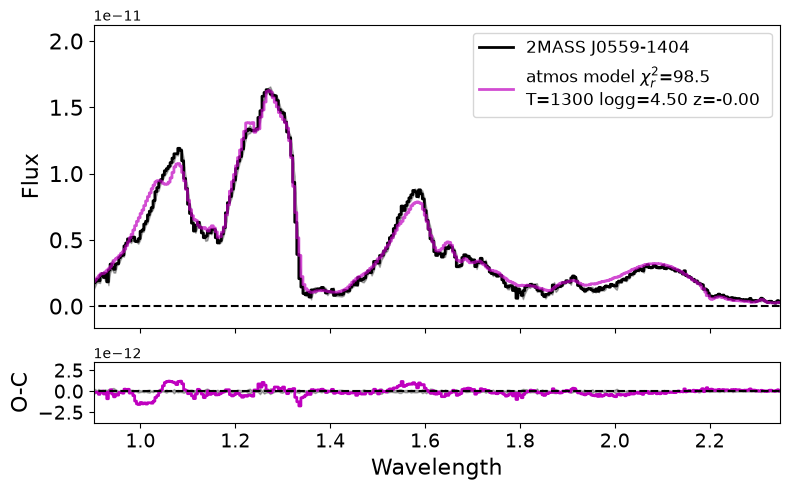

Fitting the following parameters:
	ad: initial=1.0 step=0.01 min=1.0 max=1.1
	broad: initial=A (discrete)
	cld: initial=RO (discrete)
	kzz: initial=0.0 step=0.25 min=0.0 max=8.0
	logg: initial=4.5 step=0.1 min=4.5 max=5.5
	logpmin: initial=-8.0 step=3.5 min=-8.0 max=-0.0
	teff: initial=1300.0 step=25 min=600.0 max=2000.0


In [28]:
models, wave = ucdmcmc.getModelSet("atmo20", "SPEX-PRISM")

sp = ucdmcmc.getSample(instrument='SPEX-PRISM')
sp.trim([0.9,2.35])
sp.toWavelengths(wave)

par = ucdmcmc.fitGrid(sp, models)

pfitc, pfitd, plimits = fitMCMC(sp, models, par)

In [29]:
plimits

{'ad': [1.0, 1.1],
 'broad': ['A', 'B'],
 'cld': ['LC', 'RO'],
 'kzz': [0.0, 8.0],
 'logg': [4.5, 5.5],
 'logpmin': [-8.0, -0.0],
 'teff': [600.0, 2000.0]}

In [30]:
grids = np.array(np.meshgrid(*pfitd.values(), indexing="ij"))
grids.shape

(2, 1, 1)

In [31]:
pfitc

{'ad': 1.0, 'kzz': 0.0, 'logg': 4.5, 'logpmin': -8.0, 'teff': 1300.0}

In [35]:
import itertools

list(itertools.product(*discrete_list))

[('A', 'LC'), ('A', 'RO'), ('B', 'LC'), ('B', 'RO')]

In [33]:
discrete_list = []

for key in pfitd:
    discrete_list.append(plimits[key]) #= np.vstack((discrete_array, np.array(plimits[key])))
    
discrete_list

glorp = np.array(discrete_list)


# combinations = np.array(np.meshgrid([plimits[key] for key in pfitd.keys()], indexing='ij')).T.reshape(-1, len(pfitd))

combinations = np.array(np.meshgrid(*glorp, indexing='ij')).T.reshape(-1, len(pfitd))

combinations

array([['A', 'LC'],
       ['B', 'LC'],
       ['A', 'RO'],
       ['B', 'RO']], dtype='<U2')